<a href="https://colab.research.google.com/github/Modhu54/Chemical-Engineering-Problems/blob/main/CSTR__IVP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from scipy.integrate import odeint

In [ ]:
import math
from math import *

Major governing equation of CSTR reactor

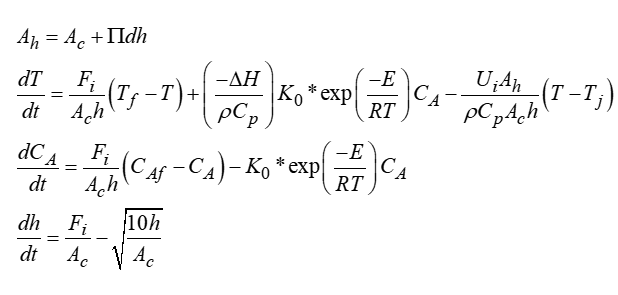

Solving ODE eqautions of CSTR using IVP method

In [ ]:

def CSTR(t,y):

  d=2.335              # Diameter of the reactor
  AC=4.2822            # Cross sectional area
  Caf=10.0             # Concentration of reactant A in the feed stream
  Me=0.14              # Ui/(RowCp)
  Y=5960.24157         # Y = E/R

  Z=34930800           # Frequency factor
  X=416375136          # X = (-HZ)/(Row*Cp)
  f=1387917120         # f = (–H*V*Z)/(Ui*Ah)

  Tj = 25                   # Initial Jacket temperature
  Fi = 10                    # Feed flow rate
  Tf = 25                    # Feed temperature

  # lets take AH - AC =m

  m  = y[0]
  T = y[1]
  Ca =y[2]
  h = y[3]




  #AH = AC+3.14159*d*h
  #AH-AC = 3.14159*d*h
  #m=3.14159*d*h
  #dm/dt = 3.14159*d*(dh/dt)
  #dm/dt = 3.14159*d*((Fi/AC)-(sqrt((10.0*h)/AC)))

  dm = 3.14159*d*((Fi/AC)-(sqrt((10.0*h)/AC)))

  #substituting Ah= AC+m


  dT = (X*Ca*exp(-Y/(273+T)))-(((Me*(AC+m))/(AC*h))*(T-Tj))+(Tf-T)*(Fi/(AC*h))

  dCa = ((Fi/(AC*h))*(Caf-Ca))-(Z*Ca*exp(-Y/(273+T)))

  dh =  (Fi/AC)-(sqrt((10.0*h)/AC))



  return [dm,dT, dCa, dh]



#p = (d,AC,Caf,Me,Y,Z,X,f,Tj,Fi,Tf )

y0 = [17.130129,120, 1, 2.335201]

t_span = [0.0, 25.0]

t_s = np.linspace(0, 25, 5000)

step_s = 0.005

solve_ivp_rk45 = solve_ivp(CSTR, t_span, y0, method='RK45', t_eval=t_s, dense_output=True, events=None, vectorized=False, first_step = step_s,rtol=0.001, atol= 0.000001,max_step=inf)
solve_ivp_DOP853 = solve_ivp(CSTR, t_span, y0, method='DOP853', t_eval=t_s, dense_output=True, events=None, vectorized=False, first_step = step_s,rtol=0.001, atol= 0.000001,max_step=inf)

solve_ivp_radau = solve_ivp(CSTR, t_span, y0, method='Radau', t_eval=t_s, dense_output=True, events=None, vectorized=False, first_step = step_s,rtol=0.001, atol= 0.000001,max_step=inf)
solve_ivp_BDF = solve_ivp(CSTR, t_span, y0, method='BDF', t_eval=t_s, dense_output=True, events=None, vectorized=False, first_step = step_s,rtol=0.001, atol= 0.000001,max_step=inf)
solve_ivp_LSODA = solve_ivp(CSTR, t_span, y0, method='LSODA', t_eval=t_s, dense_output=True, events=None, vectorized=False, first_step = step_s,rtol=0.001, atol= 0.000001,max_step=inf)
#solve_odeint = odeint(CSTR, y0, t_span)

#with RK45
m = solve_ivp_rk45.y[0,:]
T_RK45 = solve_ivp_rk45.y[1,:]
Ca_RK45 = solve_ivp_rk45.y[2,:]
h = solve_ivp_rk45.y[3,:]

#WITH OTHER SOLVER

T_DOP853 = solve_ivp_DOP853.y[1,:]
T_Radau = solve_ivp_radau.y[1,:]
T_BDF = solve_ivp_BDF.y[1,:]
T_LSODA = solve_ivp_LSODA.y[1,:]


Ca_DOP853 = solve_ivp_DOP853.y[2,:]
Ca_Radau = solve_ivp_radau.y[2,:]
Ca_BDF = solve_ivp_BDF.y[2,:]
Ca_LSODA = solve_ivp_LSODA.y[2,:]




([<matplotlib.axis.XTick at 0x783999740ec0>,
 [Text(0, 0, '0'),
  Text(5, 0, '5'),
  Text(10, 0, '10'),
  Text(15, 0, '15'),
  Text(20, 0, '20'),
  Text(25, 0, '25')])

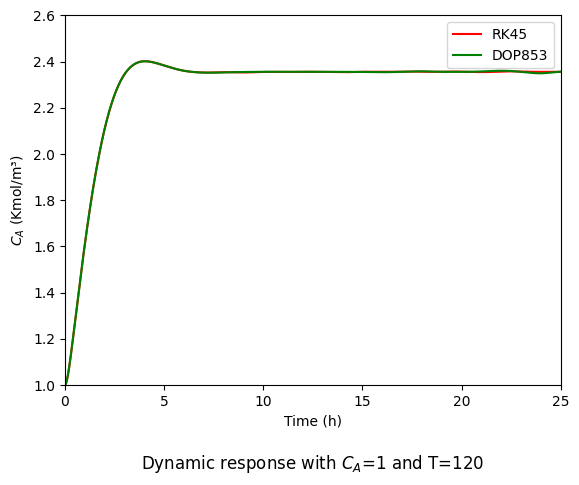

In [ ]:
#ploTS for concentration WITH Explicit method

plt.plot(solve_ivp_rk45.t,Ca_RK45, color = 'red' ,label= 'RK45')
plt.plot(solve_ivp_DOP853.t,Ca_DOP853, color = 'GREEN' ,label= 'DOP853')
plt.legend()

plt.axvline(x=0, c="black",linewidth=0.5)
plt.axhline(y=0, c="black",linewidth=0.5)
plt.title("Dynamic response with $C_{A}$=1 and T=120", y=-0.25)
plt.xlabel('Time (h)')
plt.ylabel(r'$C_{A}$' ' (Kmol/m\u00b3)')
plt.ylim([1,2.6])
plt.xlim([0,25])
plt.yticks(np.arange(1, 2.7, 0.2))
plt.xticks(np.arange(0, 26, 5))


([<matplotlib.axis.XTick at 0x783999578ec0>,
 [Text(0, 0, '0'),
  Text(5, 0, '5'),
  Text(10, 0, '10'),
  Text(15, 0, '15'),
  Text(20, 0, '20'),
  Text(25, 0, '25')])

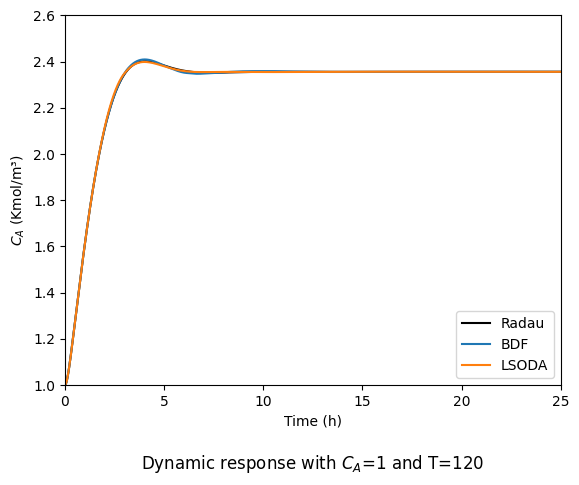

In [ ]:
#ploTS for concentration WITH Implicit method

plt.plot(solve_ivp_radau.t,Ca_Radau, color = 'BLACK',label= 'Radau')
plt.plot(solve_ivp_BDF.t,Ca_BDF, label= 'BDF')
plt.plot(solve_ivp_LSODA.t,Ca_LSODA, label= 'LSODA')
plt.legend()

plt.axvline(x=0, c="black",linewidth=0.5)
plt.axhline(y=0, c="black",linewidth=0.5)
plt.title("Dynamic response with $C_{A}$=1 and T=120", y=-0.25)
plt.xlabel('Time (h)')
plt.ylabel(r'$C_{A}$' ' (Kmol/m\u00b3)')
plt.ylim([1,2.6])
plt.xlim([0,25])
plt.yticks(np.arange(1, 2.7, 0.2))
plt.xticks(np.arange(0, 26, 5))

([<matplotlib.axis.XTick at 0x78399964b0b0>,
 [Text(0, 0, '0'),
  Text(5, 0, '5'),
  Text(10, 0, '10'),
  Text(15, 0, '15'),
  Text(20, 0, '20'),
  Text(25, 0, '25')])

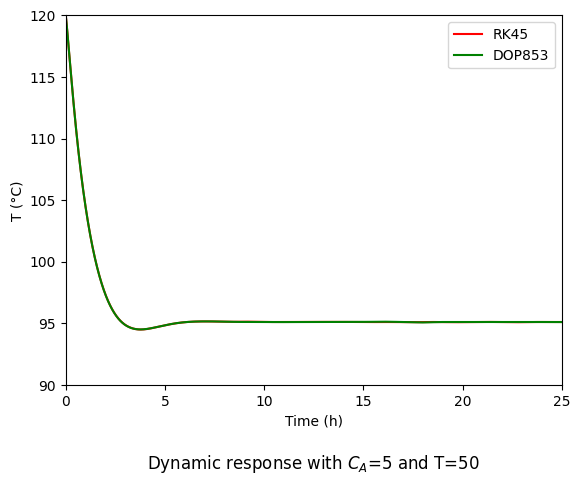

In [ ]:
#ploTS for temperature  WITH Explicit method

plt.plot(solve_ivp_rk45.t,T_RK45, color = 'red' , label= 'RK45')
plt.plot(solve_ivp_DOP853.t,T_DOP853, color = 'GREEN' ,label= 'DOP853')
plt.legend()

plt.axvline(x=0, c="black",linewidth=0.5)
plt.axhline(y=0, c="black",linewidth=0.5)
plt.title("Dynamic response with $C_{A}$=5 and T=50", y=-0.25)
plt.xlabel('Time (h)')
plt.ylabel('T (°C)')
plt.ylim([90, 120])
plt.xlim([0,25])
plt.yticks(np.arange(90, 121, 5))
plt.xticks(np.arange(0, 26, 5))


([<matplotlib.axis.XTick at 0x783999635d30>,
 [Text(0, 0, '0'),
  Text(5, 0, '5'),
  Text(10, 0, '10'),
  Text(15, 0, '15'),
  Text(20, 0, '20'),
  Text(25, 0, '25')])

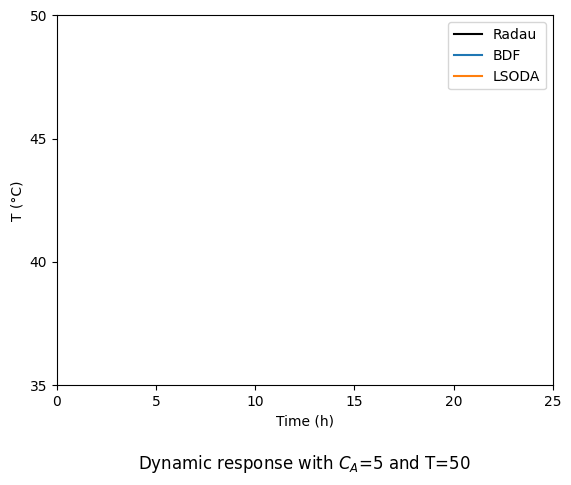

In [ ]:
#ploTS for temperature  WITH Implicit method

plt.plot(solve_ivp_radau.t,T_Radau, color = 'BLACK', label= 'Radau')
plt.plot(solve_ivp_BDF.t,T_BDF, label= 'BDF')
plt.plot(solve_ivp_LSODA.t,T_LSODA, label= 'LSODA')
plt.legend()

plt.axvline(x=0, c="black",linewidth=0.5)
plt.axhline(y=0, c="black",linewidth=0.5)
plt.title("Dynamic response with $C_{A}$=5 and T=50", y=-0.25)
plt.xlabel('Time (h)')
plt.ylabel('T (°C)')
plt.ylim([35, 50])
plt.xlim([0,25])
plt.yticks(np.arange(35, 51, 5))
plt.xticks(np.arange(0, 26, 5))

